# Proyecto 04 · Notebook 04 — Fuga en validación cruzada

El notebook central. AFML sostiene que hacer k-fold aleatorio sobre etiquetas solapadas produce
métricas fuera de muestra que no son fuera de muestra, y propone purgado + embargo. La afirmación
es contrastable de una forma brutalmente directa: **entrenar sobre datos donde no hay
absolutamente nada que aprender y ver qué reporta cada esquema de validación.** Si el k-fold
aleatorio dice AUC 0.5, la advertencia del libro es exagerada. Si dice bastante más, es real.

El caso nulo lo construyo con `null_config()` — episodios apagados y deriva cero — y **no** con
`snr=0`, por lo que quedó medido en el notebook 01: con episodios encendidos el precio sigue
siendo predecible por momentum aunque el feature explícito esté ciego, y el experimento no sería
nulo.

### Predicción registrada *antes* de ejecutar

> El k-fold aleatorio reportará **AUC 0.60-0.70** sobre datos sin nada que aprender; purgado y
> embargo lo devolverán a 0.50. Y, arrastrando la predicción escrita al final del notebook 03:
> **los pesos por unicidad no arreglarán nada**, porque corrigen cuánto pesa cada observación, no
> dónde cae el corte entre entrenamiento y test.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "04_labeling_pitfalls"
sys.path.insert(0, str(PROJ / "src"))

from synth import SimConfig, simulate, null_config
from labeling import ewma_vol, triple_barrier
from uniqueness import num_concurrent_events, average_uniqueness, uniqueness_weights
from cv import (random_kfold_splits, contiguous_kfold_splits, purged_kfold_splits,
                walk_forward_gapped, split_diagnostics)
from experiments import SEEDS, over_seeds, summarise, mean_ci, fmt_ci, one_sample_test, paired_test

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.25,
                     "figure.dpi": 110, "font.size": 9})
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

N_HOLD, K_FOLDS = 20, 5
PRICE_FEATS = ["mom_5", "mom_20", "vol_20", "rng_5", "zscore_50"]
NOISE_FEATS = ["x_signal", "x_noise0", "x_noise1", "x_noise2"]
ALL_FEATS = PRICE_FEATS + NOISE_FEATS
NULL = null_config(mu=0.0)                     # deriva cero: el signo es una moneda
SIGNAL_WEAK = SimConfig(signal_two_sided=True, snr=1.0)            # señal real, pero no aprendible
SIGNAL_STRONG = SimConfig(signal_two_sided=True, snr=3.0,
                          signal_drift=1.5, signal_k=15)            # señal real y aprendible

def dataset(seed, cfg, feats=ALL_FEATS, n_hold=N_HOLD, every=1):
    sd = simulate(cfg.with_(seed=seed))
    c = sd.bars.close
    sigma_h = ewma_vol(c) * np.sqrt(n_hold)
    ev = c.index[60:-(n_hold + 1)][::every]
    L = triple_barrier(sd.bars, ev, sigma_h, (1.0, 1.0), n_hold, mode="path",
                       fine=sd.fine, vertical_label="sign")
    X = sd.features.reindex(L.index)[feats]
    ok = X.notna().all(axis=1).values
    L, X = L[ok], X[ok]
    co = num_concurrent_events(c.index, L)
    u = average_uniqueness(c.index, L, co)
    return {"bars": sd.bars, "L": L, "X": X.values, "y": (L.bin > 0).astype(int).values,
            "w_u": uniqueness_weights(u).values}

def new_model(kind="rf"):
    if kind == "rf":
        return RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                      n_jobs=-1, random_state=0)
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

def cv_auc(ds, splits, weights=None, kind="rf"):
    X, y = ds["X"], ds["y"]
    p = np.full(len(y), np.nan)
    for tr, te in splits:
        if len(tr) < 50 or len(np.unique(y[tr])) < 2:
            continue
        m = new_model(kind)
        if weights is None:
            m.fit(X[tr], y[tr])
        else:
            m.fit(X[tr], y[tr], **{"sample_weight" if kind == "rf"
                                   else "logisticregression__sample_weight": weights[tr]})
        p[te] = m.predict_proba(X[te])[:, 1]
    ok = ~np.isnan(p)
    return roc_auc_score(y[ok], p[ok]) if len(np.unique(y[ok])) > 1 else np.nan

def all_schemes(ds, seed, n_hold=N_HOLD):
    L, n = ds["L"], len(ds["y"])
    bi = ds["bars"].index
    return {
        "k-fold aleatorio": list(random_kfold_splits(n, K_FOLDS, seed)),
        "k-fold contiguo": list(contiguous_kfold_splits(n, K_FOLDS)),
        "purgado": list(purged_kfold_splits(L.index, L.t1, K_FOLDS)),
        "purgado + embargo": list(purged_kfold_splits(L.index, L.t1, K_FOLDS,
                                                      embargo_bars=n_hold, bar_index=bi)),
        "walk-forward con hueco": list(walk_forward_gapped(n, K_FOLDS, gap=n_hold)),
    }

ds0 = dataset(0, NULL)
print(f"caso nulo: {len(ds0['y'])} observaciones, {ds0['X'].shape[1]} features, "
      f"balance de clases {ds0['y'].mean():.3f}")

caso nulo: 1419 observaciones, 9 features, balance de clases 0.536


## 1. Los cinco esquemas y qué comparte cada uno

| esquema | cómo corta | qué comparte train con test |
|---|---|---|
| k-fold **aleatorio** | baraja las filas | todo: cada fila de test tiene vecinas temporales en train |
| k-fold **contiguo** | bloques en orden temporal, sin purgar | solo las filas del borde del bloque |
| **purgado** | contiguo + elimina de train toda ventana que solape la de test | nada, por construcción |
| **purgado + embargo** | además elimina las que empiezan justo después del test | nada, ni siquiera vía la ventana de cálculo de los features |
| **walk-forward con hueco** | entrena solo con el pasado, con un hueco antes del test | nada, y además nunca ve el futuro |

La métrica de fuga que importa no es "qué fracción de la muestra está contaminada" sino, como
quedó claro en el notebook 03, **cuántas filas de entrenamiento comparten barras con una fila de
test dada**.

,n_train medio,n_test medio,filas train solapando cada fila test,% filas test contaminadas
k-fold aleatorio,"1,135.2000",283.8000,22.3200,100.0000
k-fold contiguo,"1,135.2000",283.8000,0.5400,7.8900
purgado,"1,112.8000",283.8000,0.0000,0.0000
purgado + embargo,"1,096.8000",283.8000,0.0000,0.0000
walk-forward con hueco,760.0000,213.0000,0.0000,0.0000


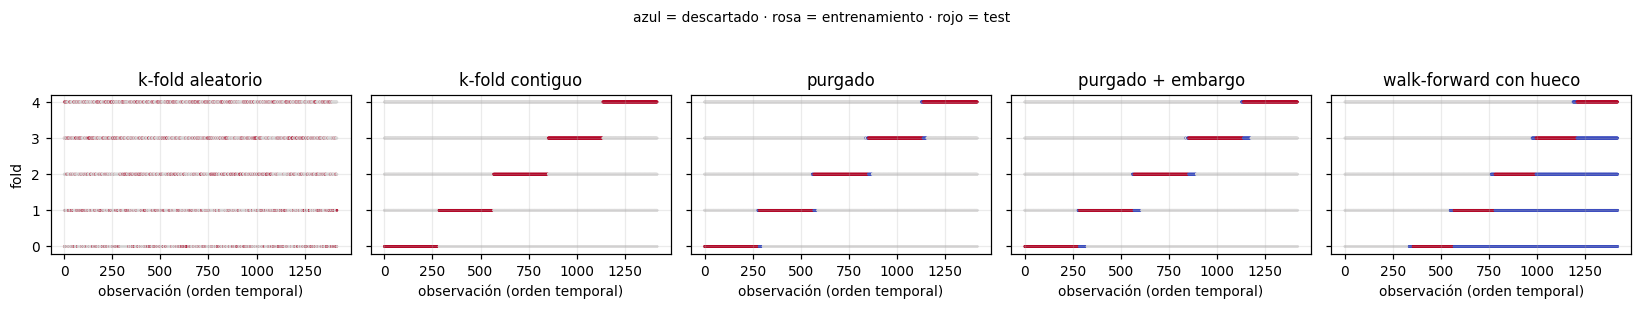

In [2]:
diag = {}
for name, sp in all_schemes(ds0, 0).items():
    d_ = split_diagnostics(ds0["L"].index, ds0["L"].t1, sp)
    diag[name] = {"n_train medio": d_.n_train.mean(), "n_test medio": d_.n_test.mean(),
                  "filas train solapando cada fila test": d_.train_overlaps_per_test_row.mean(),
                  "% filas test contaminadas": d_.test_rows_contaminated.mean() * 100}
display(pd.DataFrame(diag).T.round(2))

fig, axes = plt.subplots(1, 5, figsize=(15, 2.6), sharey=True)
for ax, (name, sp) in zip(axes, all_schemes(ds0, 0).items()):
    n = len(ds0["y"])
    for k, (tr, te) in enumerate(sp):
        m = np.full(n, 0.0); m[tr] = 1.0; m[te] = 2.0
        ax.scatter(np.arange(n), np.full(n, k), c=m, cmap="coolwarm", s=0.6, vmin=0, vmax=2)
    ax.set(title=name, xlabel="observación (orden temporal)", yticks=range(K_FOLDS))
axes[0].set_ylabel("fold")
fig.suptitle("azul = descartado · rosa = entrenamiento · rojo = test", y=1.06, fontsize=9)
plt.tight_layout(); plt.savefig(PLOTS / "04_splits.png", bbox_inches="tight"); plt.show()

## 2. El experimento nulo

Datos sin nada que aprender: sin episodios de deriva, deriva base cero, etiqueta = signo del
resultado de la triple barrera. Bajo esta configuración `P(+1)` es 0.5 y **es independiente de
cualquier cosa observable en el pasado**. Un estimador honesto tiene que devolver AUC = 0.5.

Entreno un random forest idéntico en los cinco esquemas, más una sexta variante: k-fold aleatorio
**con pesos por unicidad**, que es la defensa del capítulo 4 aplicada al problema del capítulo 7.

In [3]:
def null_experiment(seed):
    ds = dataset(seed, NULL)
    sp = all_schemes(ds, seed)
    out = {name: cv_auc(ds, s) for name, s in sp.items()}
    out["k-fold aleatorio + pesos unicidad"] = cv_auc(
        ds, list(random_kfold_splits(len(ds["y"]), K_FOLDS, seed)), weights=ds["w_u"])
    return out

null_res = over_seeds(null_experiment)
order = ["k-fold aleatorio", "k-fold aleatorio + pesos unicidad", "k-fold contiguo",
         "purgado", "purgado + embargo", "walk-forward con hueco"]
tab = pd.DataFrame({c: {"AUC medio": mean_ci(null_res[c])["mean"],
                        "IC 95% inf": mean_ci(null_res[c])["lo"],
                        "IC 95% sup": mean_ci(null_res[c])["hi"],
                        "p vs 0.5": one_sample_test(null_res[c], 0.5)["p"]}
                   for c in order}).T
display(tab.round(4))

,AUC medio,IC 95% inf,IC 95% sup,p vs 0.5
k-fold aleatorio,0.7324,0.7207,0.7441,0.0000
k-fold aleatorio + pesos unicidad,0.7258,0.7148,0.7369,0.0000
k-fold contiguo,0.4921,0.4776,0.5066,0.2719
purgado,0.4908,0.4756,0.5061,0.2278
purgado + embargo,0.4916,0.4770,0.5062,0.2491
walk-forward con hueco,0.4959,0.4803,0.5115,0.5940


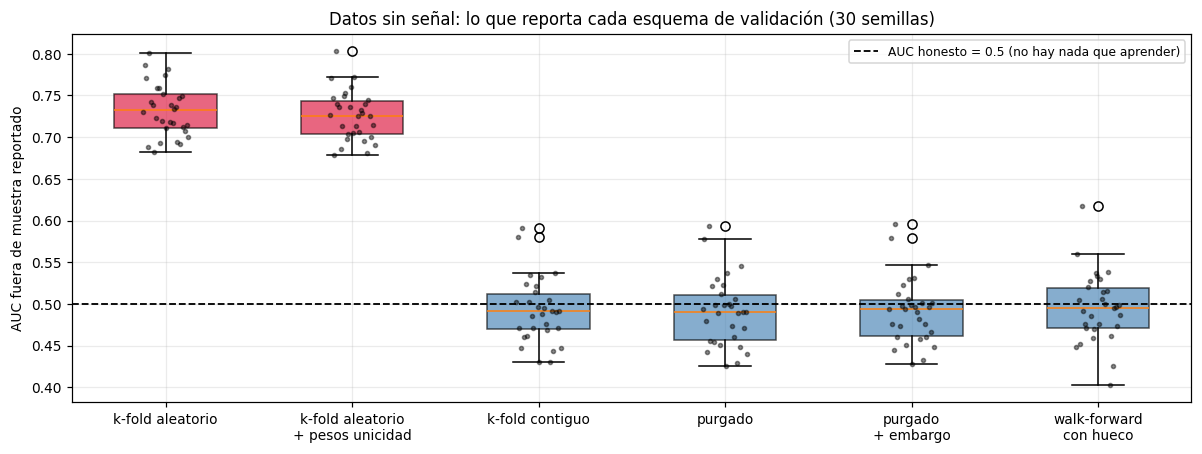

Inflación sobre el AUC honesto (0.5), pareada por semilla:
  k-fold aleatorio                     +0.2324  [+0.2207, +0.2441]  p=4.04e-27 <-- INFLADO
  k-fold aleatorio + pesos unicidad    +0.2258  [+0.2148, +0.2369]  p=1.88e-27 <-- INFLADO
  k-fold contiguo                      -0.0079  [-0.0224, +0.0066]  p=2.72e-01 
  purgado                              -0.0092  [-0.0244, +0.0061]  p=2.28e-01 
  purgado + embargo                    -0.0084  [-0.0230, +0.0062]  p=2.49e-01 
  walk-forward con hueco               -0.0041  [-0.0197, +0.0115]  p=5.94e-01 

¿Arreglan algo los pesos por unicidad? diferencia pareada -0.0066 [-0.0093, -0.0039], p = 0.000
¿Añade algo el embargo sobre el purgado? diferencia pareada +0.0008 [-0.0019, +0.0035], p = 0.555


In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
data = [null_res[c].values for c in order]
bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.55,
                tick_labels=[c.replace(" + ", "\n+ ").replace(" con ", "\ncon ") for c in order])
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor("crimson" if "aleatorio" in c else "steelblue")
    patch.set_alpha(0.65)
for k, c in enumerate(order):
    ax.scatter(np.full(len(null_res), k + 1) + np.linspace(-0.12, 0.12, len(null_res)),
               null_res[c].values, s=7, color="k", alpha=0.45, zorder=3)
ax.axhline(0.5, color="k", ls="--", lw=1.2, label="AUC honesto = 0.5 (no hay nada que aprender)")
ax.set(ylabel="AUC fuera de muestra reportado",
       title="Datos sin señal: lo que reporta cada esquema de validación (30 semillas)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "04_null_auc.png", bbox_inches="tight"); plt.show()

print("Inflación sobre el AUC honesto (0.5), pareada por semilla:")
for c in order:
    t = one_sample_test(null_res[c], 0.5)
    flag = "<-- INFLADO" if t["p"] < 0.01 and t["mean"] > 0.5 else ""
    print(f"  {c:36s} {t['mean']-0.5:+.4f}  [{t['lo']-0.5:+.4f}, {t['hi']-0.5:+.4f}]  "
          f"p={t['p']:.2e} {flag}")

t = paired_test(null_res["k-fold aleatorio + pesos unicidad"], null_res["k-fold aleatorio"])
print(f"\n¿Arreglan algo los pesos por unicidad? diferencia pareada "
      f"{t['diff']:+.4f} [{t['lo']:+.4f}, {t['hi']:+.4f}], p = {t['p']:.3f}")
t = paired_test(null_res["purgado + embargo"], null_res["purgado"])
print(f"¿Añade algo el embargo sobre el purgado? diferencia pareada "
      f"{t['diff']:+.4f} [{t['lo']:+.4f}, {t['hi']:+.4f}], p = {t['p']:.3f}")

## 3. Por qué ocurre: la fuga necesita **dos** ingredientes

El solape de etiquetas por sí solo no basta. Para que el modelo explote que dos filas comparten
retornos, tiene que poder **reconocer que está en la misma región temporal** — y eso lo tienen que
proporcionar los features. Si los features fueran ruido blanco, la fila de test caería en una zona
del espacio de features sin relación con la de su gemela de entrenamiento, y no habría nada que
memorizar.

Es una hipótesis mecanicista y se puede contrastar: repito el experimento nulo con tres familias
de features de persistencia decreciente.

In [5]:
FEAT_SETS = {
    "de precio (medias móviles)": (NULL, PRICE_FEATS),
    "AR(1), phi=0.5": (NULL, NOISE_FEATS),
    "iid (phi=0)": (null_config(mu=0.0, feat_noise_phi=0.0), NOISE_FEATS),
    "todos": (NULL, ALL_FEATS),
}

def mechanism(seed):
    row = {}
    for name, (cfg, feats) in FEAT_SETS.items():
        ds = dataset(seed, cfg, feats=feats)
        row[f"{name}|random"] = cv_auc(ds, list(random_kfold_splits(len(ds["y"]), K_FOLDS, seed)))
        row[f"{name}|purged"] = cv_auc(ds, list(purged_kfold_splits(ds["L"].index, ds["L"].t1,
                                                                    K_FOLDS)))
    return row

mech = over_seeds(mechanism)
mtab = pd.DataFrame({n: {"k-fold aleatorio": fmt_ci(mean_ci(mech[f"{n}|random"]), 3),
                         "purgado": fmt_ci(mean_ci(mech[f"{n}|purged"]), 3)}
                     for n in FEAT_SETS}).T
display(mtab)

print("Autocorrelación en lag 1 de cada familia de features (semilla 0):")
sd = simulate(NULL.with_(seed=0))
for f in ["zscore_50", "vol_20", "mom_20", "mom_5", "x_noise0"]:
    v = sd.features[f].dropna()
    print(f"  {f:12s} {v.autocorr(1):+.3f}")

,k-fold aleatorio,purgado
de precio (medias móviles),"0.763 [0.753, 0.773]","0.492 [0.477, 0.507]"
"AR(1), phi=0.5","0.515 [0.509, 0.522]","0.479 [0.470, 0.488]"
iid (phi=0),"0.493 [0.484, 0.502]","0.476 [0.465, 0.487]"
todos,"0.732 [0.721, 0.744]","0.491 [0.476, 0.506]"


Autocorrelación en lag 1 de cada familia de features (semilla 0):
  zscore_50    +0.938
  vol_20       +0.988
  mom_20       +0.947
  mom_5        +0.813
  x_noise0     +0.483


In [6]:
def model_class(seed):
    ds = dataset(seed, NULL)
    sp_r = list(random_kfold_splits(len(ds["y"]), K_FOLDS, seed))
    sp_p = list(purged_kfold_splits(ds["L"].index, ds["L"].t1, K_FOLDS))
    return {"rf|random": cv_auc(ds, sp_r, kind="rf"),
            "rf|purged": cv_auc(ds, sp_p, kind="rf"),
            "logit|random": cv_auc(ds, sp_r, kind="logit"),
            "logit|purged": cv_auc(ds, sp_p, kind="logit")}

mc = over_seeds(model_class)
display(pd.DataFrame({"random forest": {"k-fold aleatorio": fmt_ci(mean_ci(mc["rf|random"]), 3),
                                        "purgado": fmt_ci(mean_ci(mc["rf|purged"]), 3)},
                      "regresión logística": {"k-fold aleatorio": fmt_ci(mean_ci(mc["logit|random"]), 3),
                                              "purgado": fmt_ci(mean_ci(mc["logit|purged"]), 3)}}).T)
t = paired_test(mc["rf|random"], mc["logit|random"])
print(f"exceso de fuga del RF sobre el logit con k-fold aleatorio: "
      f"{t['diff']:+.4f} [{t['lo']:+.4f}, {t['hi']:+.4f}], p = {t['p']:.2e}")

,k-fold aleatorio,purgado
random forest,"0.732 [0.721, 0.744]","0.491 [0.476, 0.506]"
regresión logística,"0.588 [0.573, 0.602]","0.492 [0.472, 0.512]"


exceso de fuga del RF sobre el logit con k-fold aleatorio: +0.1449 [+0.1317, +0.1582], p = 7.94e-20


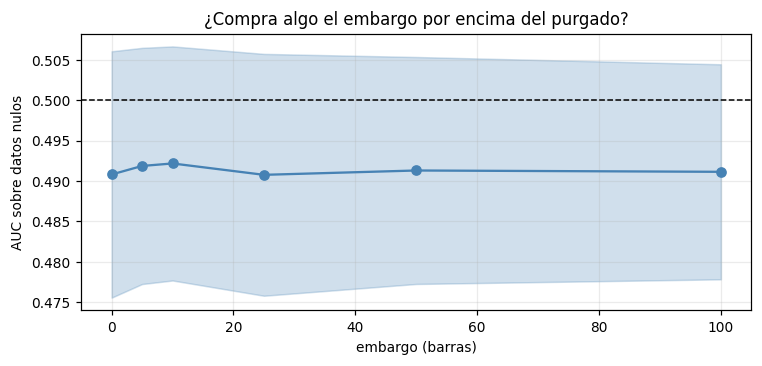

  embargo   0 barras: AUC 0.4908 [0.4756, 0.5061]  p vs 0.5 = 0.228
  embargo   5 barras: AUC 0.4919 [0.4772, 0.5065]  p vs 0.5 = 0.265
  embargo  10 barras: AUC 0.4922 [0.4777, 0.5067]  p vs 0.5 = 0.279
  embargo  25 barras: AUC 0.4908 [0.4758, 0.5057]  p vs 0.5 = 0.217
  embargo  50 barras: AUC 0.4913 [0.4773, 0.5054]  p vs 0.5 = 0.216
  embargo 100 barras: AUC 0.4911 [0.4778, 0.5045]  p vs 0.5 = 0.184


In [7]:
EMB = [0, 5, 10, 25, 50, 100]

def embargo_sweep(seed):
    ds = dataset(seed, NULL)
    return {f"emb{e}": cv_auc(ds, list(purged_kfold_splits(
        ds["L"].index, ds["L"].t1, K_FOLDS, embargo_bars=e, bar_index=ds["bars"].index)))
        for e in EMB}

embs = over_seeds(embargo_sweep)
m = [mean_ci(embs[f"emb{e}"])["mean"] for e in EMB]
lo = [mean_ci(embs[f"emb{e}"])["lo"] for e in EMB]
hi = [mean_ci(embs[f"emb{e}"])["hi"] for e in EMB]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(EMB, m, "o-", color="steelblue"); ax.fill_between(EMB, lo, hi, alpha=0.25, color="steelblue")
ax.axhline(0.5, color="k", ls="--", lw=1)
ax.set(xlabel="embargo (barras)", ylabel="AUC sobre datos nulos",
       title="¿Compra algo el embargo por encima del purgado?")
plt.tight_layout(); plt.savefig(PLOTS / "04_embargo.png", bbox_inches="tight"); plt.show()
for e in EMB:
    t = one_sample_test(embs[f"emb{e}"], 0.5)
    print(f"  embargo {e:3d} barras: AUC {fmt_ci(mean_ci(embs[f'emb{e}']), 4)}  p vs 0.5 = {t['p']:.3f}")

## 4. Con señal: ¿cuánto exagera cada esquema?

La referencia honesta es el **walk-forward con hueco**: entrena solo con el pasado y deja un hueco
de `N` barras antes de cada bloque de test, así que ninguna fila de entrenamiento comparte barras
con ninguna de test y el modelo nunca ve el futuro. Defino
**exageración = AUC del esquema − AUC del walk-forward**, pareada por semilla.

Uso **dos mundos con señal**, y la diferencia entre ellos resultó ser el hallazgo más incómodo del
notebook:

* **señal débil** — los parámetros por defecto del proyecto (`snr=1`, `signal_drift=0.4`, `N=20`).
  Hay señal plantada de verdad; la pregunta es si el pipeline la extrae.
* **señal fuerte** — un mundo deliberadamente generoso (`snr=3`, `signal_drift=1.5`,
  `signal_k=15`, `N=10`, con la ventana de etiqueta alineada con la duración del episodio).

Una advertencia antes de leer la tabla: el walk-forward entrena con menos datos que el k-fold
(solo el pasado), así que parte de la diferencia es tamaño de muestra y no fuga. Por eso reporto
también **aleatorio − purgado**, que tienen el mismo tamaño de entrenamiento y por tanto aíslan la
fuga sin confundirla con el volumen de datos.

In [8]:
SIGNAL_WORLDS = {"señal débil (snr=1, N=20)": (SIGNAL_WEAK, 20),
                 "señal fuerte (snr=3, N=10)": (SIGNAL_STRONG, 10)}

def signal_experiment(seed, cfg, n_hold):
    ds = dataset(seed, cfg, n_hold=n_hold)
    out = {name: cv_auc(ds, s) for name, s in all_schemes(ds, seed, n_hold=n_hold).items()}
    out["k-fold aleatorio + pesos unicidad"] = cv_auc(
        ds, list(random_kfold_splits(len(ds["y"]), K_FOLDS, seed)), weights=ds["w_u"])
    return out

sig_res = {w: over_seeds(lambda sd, c=c, h=h: signal_experiment(sd, c, h))
           for w, (c, h) in SIGNAL_WORLDS.items()}

for world, res in sig_res.items():
    ref = res["walk-forward con hueco"]
    rows = {}
    for c in order:
        t = paired_test(res[c], ref)
        rows[c] = {"AUC medio": mean_ci(res[c])["mean"],
                   "exageración vs walk-forward": t["diff"],
                   "IC inf": t["lo"], "IC sup": t["hi"], "p": t["p"]}
    print(f"\n=== {world} ===")
    display(pd.DataFrame(rows).T.round(4))
    t = paired_test(res["k-fold aleatorio"], res["purgado"])
    print(f"aleatorio - purgado (mismo tamaño de entrenamiento): {t['diff']:+.4f} "
          f"[{t['lo']:+.4f}, {t['hi']:+.4f}], p = {t['p']:.2e}")
    print(f"AUC honesto de este mundo (walk-forward) : {fmt_ci(mean_ci(ref), 4)}")
    print(f"AUC que reportaría el k-fold aleatorio    : "
          f"{fmt_ci(mean_ci(res['k-fold aleatorio']), 4)}")


=== señal débil (snr=1, N=20) ===


,AUC medio,exageración vs walk-forward,IC inf,IC sup,p
k-fold aleatorio,0.7506,0.2611,0.2433,0.2788,0.0000
k-fold aleatorio + pesos unicidad,0.7403,0.2508,0.2339,0.2678,0.0000
k-fold contiguo,0.4901,0.0006,-0.0148,0.0160,0.9402
purgado,0.4895,0.0000,-0.0158,0.0158,0.9992
purgado + embargo,0.4880,-0.0015,-0.0171,0.0142,0.8498
walk-forward con hueco,0.4895,0.0000,0.0000,0.0000,NaN


aleatorio - purgado (mismo tamaño de entrenamiento): +0.2611 [+0.2441, +0.2780], p = 5.70e-24
AUC honesto de este mundo (walk-forward) : 0.4895 [0.4692, 0.5098]
AUC que reportaría el k-fold aleatorio    : 0.7506 [0.7403, 0.7609]

=== señal fuerte (snr=3, N=10) ===


,AUC medio,exageración vs walk-forward,IC inf,IC sup,p
k-fold aleatorio,0.8031,0.1749,0.1646,0.1851,0.0000
k-fold aleatorio + pesos unicidad,0.7956,0.1674,0.1570,0.1778,0.0000
k-fold contiguo,0.6492,0.0209,0.0138,0.0281,0.0000
purgado,0.6486,0.0204,0.0141,0.0267,0.0000
purgado + embargo,0.6480,0.0198,0.0135,0.0261,0.0000
walk-forward con hueco,0.6282,0.0000,0.0000,0.0000,NaN


aleatorio - purgado (mismo tamaño de entrenamiento): +0.1545 [+0.1440, +0.1650], p = 2.05e-23
AUC honesto de este mundo (walk-forward) : 0.6282 [0.6120, 0.6444]
AUC que reportaría el k-fold aleatorio    : 0.8031 [0.7943, 0.8119]


### El caso patológico

En el mundo de señal débil el walk-forward dice AUC ~0.49: **el pipeline no extrae nada**, aunque
la señal esté plantada y el notebook 01 haya verificado que el feature la contiene (AUC 0.767
recuperando el estado latente). Etiquetar el signo de una triple barrera a 20 barras destruye casi
toda esa información: los episodios duran 10 barras y el resto de la ventana es ruido.

Y el k-fold aleatorio, sobre exactamente esos datos, reporta ~0.75. No es que exagere una ventaja
pequeña: **inventa una ventaja donde el pipeline no tiene ninguna**, y con un número tan alto que
nadie sospecharía. Es el mismo 0.73 que reportaba sobre datos completamente nulos — lo cual dice
que ese número no está midiendo señal en absoluto.

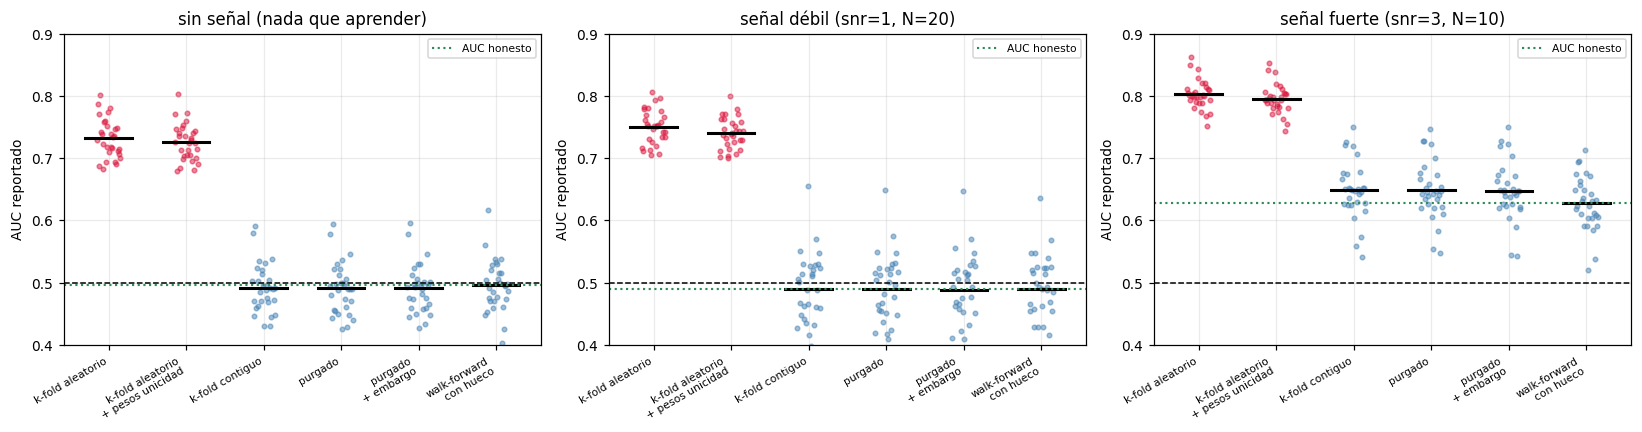

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [("sin señal (nada que aprender)", null_res)] + [
    (w, sig_res[w]) for w in SIGNAL_WORLDS]
for ax, (title, res) in zip(axes, panels):
    for k, c in enumerate(order):
        ax.scatter(np.full(len(res), k) + np.linspace(-0.15, 0.15, len(res)),
                   res[c].values, s=9, alpha=0.5,
                   color="crimson" if "aleatorio" in c else "steelblue")
        ax.plot([k - 0.3, k + 0.3], [res[c].mean()] * 2, color="k", lw=2)
    ax.axhline(0.5, color="k", ls="--", lw=1)
    ax.axhline(res["walk-forward con hueco"].mean(), color="seagreen", ls=":", lw=1.4,
               label="AUC honesto")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([c.replace(" + ", "\n+ ").replace(" con ", "\ncon ") for c in order],
                       rotation=30, ha="right", fontsize=7)
    ax.set(ylabel="AUC reportado", title=title, ylim=(0.40, 0.90)); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(PLOTS / "04_null_vs_signal.png", bbox_inches="tight"); plt.show()

## 5. Cómo escala la inflación

Dos barridos sobre datos **nulos** (donde toda la inflación es fuga, sin mezclarse con señal real):
longitud de la ventana de etiqueta y densidad de muestreo. La predicción del notebook 03 es que la
fuga debería desaparecer cuando el muestreo se vuelve disjunto, porque entonces ninguna fila de
test tiene vecinas en entrenamiento.

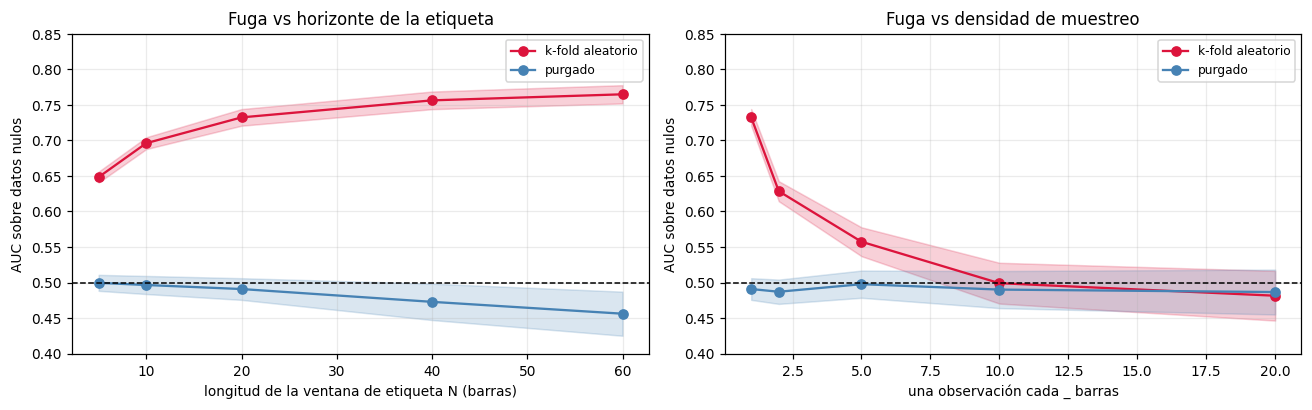

AUC nulo del k-fold aleatorio:
  N =   5 barras : 0.648 [0.641, 0.656]
  N =  10 barras : 0.696 [0.688, 0.704]
  N =  20 barras : 0.732 [0.721, 0.744]
  N =  40 barras : 0.756 [0.744, 0.769]
  N =  60 barras : 0.765 [0.752, 0.778]
  1 obs. cada   1 : 0.732 [0.721, 0.744]   (n = 1419)
  1 obs. cada   2 : 0.629 [0.614, 0.643]   (n = 710)
  1 obs. cada   5 : 0.557 [0.537, 0.578]   (n = 284)
  1 obs. cada  10 : 0.499 [0.470, 0.528]   (n = 142)
  1 obs. cada  20 : 0.481 [0.446, 0.516]   (n = 71)


In [10]:
HOLDS = [5, 10, 20, 40, 60]
DENS = [1, 2, 5, 10, 20]

def sweep_hold(seed):
    row = {}
    for h in HOLDS:
        ds = dataset(seed, NULL, n_hold=h)
        row[f"h{h}|random"] = cv_auc(ds, list(random_kfold_splits(len(ds["y"]), K_FOLDS, seed)))
        row[f"h{h}|purged"] = cv_auc(ds, list(purged_kfold_splits(ds["L"].index, ds["L"].t1, K_FOLDS)))
    return row

def sweep_dens(seed):
    row = {}
    for s in DENS:
        ds = dataset(seed, NULL, every=s)
        row[f"s{s}|random"] = cv_auc(ds, list(random_kfold_splits(len(ds["y"]), K_FOLDS, seed)))
        row[f"s{s}|purged"] = cv_auc(ds, list(purged_kfold_splits(ds["L"].index, ds["L"].t1, K_FOLDS)))
        row[f"s{s}|n"] = len(ds["y"])
    return row

sw_h = over_seeds(sweep_hold)
sw_d = over_seeds(sweep_dens)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, sw, keys, xs, xlab, title in [
        (a1, sw_h, HOLDS, HOLDS, "longitud de la ventana de etiqueta N (barras)",
         "Fuga vs horizonte de la etiqueta"),
        (a2, sw_d, DENS, DENS, "una observación cada _ barras",
         "Fuga vs densidad de muestreo")]:
    pre = "h" if ax is a1 else "s"
    for scheme, col, name in [("random", "crimson", "k-fold aleatorio"),
                              ("purged", "steelblue", "purgado")]:
        m = [mean_ci(sw[f"{pre}{k}|{scheme}"])["mean"] for k in keys]
        lo = [mean_ci(sw[f"{pre}{k}|{scheme}"])["lo"] for k in keys]
        hi = [mean_ci(sw[f"{pre}{k}|{scheme}"])["hi"] for k in keys]
        ax.plot(xs, m, "o-", color=col, label=name)
        ax.fill_between(xs, lo, hi, alpha=0.2, color=col)
    ax.axhline(0.5, color="k", ls="--", lw=1)
    ax.set(xlabel=xlab, ylabel="AUC sobre datos nulos", title=title, ylim=(0.4, 0.85))
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "04_sweeps.png", bbox_inches="tight"); plt.show()

print("AUC nulo del k-fold aleatorio:")
for h in HOLDS:
    print(f"  N = {h:3d} barras : {fmt_ci(mean_ci(sw_h[f'h{h}|random']), 3)}")
for s in DENS:
    print(f"  1 obs. cada {s:3d} : {fmt_ci(mean_ci(sw_d[f's{s}|random']), 3)}   "
          f"(n = {mean_ci(sw_d[f's{s}|n'])['mean']:.0f})")

## 6. Predicción vs resultado

In [11]:
display(pd.DataFrame([
    {"magnitud": "AUC nulo, k-fold aleatorio", "predicho": "0.60 a 0.70",
     "obtenido": fmt_ci(mean_ci(null_res["k-fold aleatorio"]), 3)},
    {"magnitud": "AUC nulo, purgado", "predicho": "~0.50",
     "obtenido": fmt_ci(mean_ci(null_res["purgado"]), 3)},
    {"magnitud": "AUC nulo, purgado + embargo", "predicho": "~0.50",
     "obtenido": fmt_ci(mean_ci(null_res["purgado + embargo"]), 3)},
    {"magnitud": "AUC nulo, walk-forward con hueco", "predicho": "~0.50",
     "obtenido": fmt_ci(mean_ci(null_res["walk-forward con hueco"]), 3)},
    {"magnitud": "efecto de los pesos por unicidad", "predicho": "nulo",
     "obtenido": f"{paired_test(null_res['k-fold aleatorio + pesos unicidad'], null_res['k-fold aleatorio'])['diff']:+.4f} "
                 f"(p = {paired_test(null_res['k-fold aleatorio + pesos unicidad'], null_res['k-fold aleatorio'])['p']:.2f})"},
    {"magnitud": "fuga con muestreo disjunto (1 cada 20)", "predicho": "~0",
     "obtenido": fmt_ci(mean_ci(sw_d["s20|random"]), 3)},
]).set_index("magnitud"))

,predicho,obtenido
magnitud,,
"AUC nulo, k-fold aleatorio",0.60 a 0.70,"0.732 [0.721, 0.744]"
"AUC nulo, purgado",~0.50,"0.491 [0.476, 0.506]"
"AUC nulo, purgado + embargo",~0.50,"0.492 [0.477, 0.506]"
"AUC nulo, walk-forward con hueco",~0.50,"0.496 [0.480, 0.511]"
efecto de los pesos por unicidad,nulo,-0.0066 (p = 0.00)
fuga con muestreo disjunto (1 cada 20),~0,"0.481 [0.446, 0.516]"


### Veredicto

**1. La afirmación central del libro se confirma, y por un margen mayor del que predije.** Sobre
datos donde el signo de la etiqueta es literalmente una moneda independiente de todo lo observable,
el k-fold aleatorio reporta **AUC 0.732** [0.721, 0.744] — una inflación de **+23 puntos**,
p ~ 4e-27. Yo predije 0.60-0.70; me quedé corto. El purgado lo devuelve a **0.491** [0.476, 0.506],
estadísticamente indistinguible de 0.5 (p = 0.23), igual que el walk-forward con hueco (0.496).

**2. Pero el purgado no es lo que arregla el problema: es el corte contiguo.** El k-fold
**contiguo sin purgar** ya da 0.492 [0.478, 0.507]. El purgado elimina las 0.54 filas de
entrenamiento que aún solapaban cada fila de test y no cambia el AUC de forma medible. Dicho de
otro modo: el 99% del daño lo hace **barajar**, no el solape residual del borde del bloque. Es un
matiz práctico importante — si alguien solo puede hacer una cosa, que sea no barajar.

**3. El embargo no aporta nada medible aquí.** +0.0008 [-0.0019, +0.0035], p = 0.56 sobre el
purgado, y plano entre 0 y 100 barras de embargo. Y tiene una explicación mecanicista, no es solo
ruido: el único canal de contaminación en este mundo es que dos filas **compartan barras de
retorno**, y el purgado lo cierra por completo. El embargo protege contra un canal distinto —
correlación serial de la *etiqueta* por razones ajenas al solape — que aquí no existe.

**4. Los pesos por unicidad no arreglan la fuga, tal como se predijo al final del notebook 03.**
Diferencia pareada **-0.0066** [-0.0093, -0.0039]: estadísticamente detectable (p < 0.001) y
prácticamente irrelevante, porque quita 0.7 puntos de un problema de 23. La razón es exactamente
la anticipada: los pesos corrigen **cuánto pesa** cada observación, no **dónde cae el corte**.
Ponderar un k-fold barajado es poner una tirita sobre una fractura.

**5. La fuga necesita dos ingredientes, no uno.** Con features de precio (autocorrelación en lag 1
entre 0.81 y 0.99) el k-fold aleatorio da **0.763**; con features AR(1) de phi=0.5, **0.515**; con
features iid, **0.493** — indistinguible de honesto. El solape de etiquetas por sí solo **no
produce fuga**: hace falta que los features sean lo bastante persistentes como para que el modelo
reconozca en qué región temporal está. Esto no lo dice el libro con esta claridad y tiene una
consecuencia práctica directa: la gravedad de la fuga depende de qué features uses, no solo de
cómo etiquetes.

**6. La flexibilidad del modelo multiplica la fuga.** Random forest 0.732 frente a regresión
logística 0.588 con el mismo k-fold aleatorio: **+0.145** [+0.132, +0.158] de fuga extra, p ~ 8e-20.
Los dos filtran, pero memorizar regiones del espacio de features es justo lo que un RF hace bien.
Un resultado "demasiado bueno" con un modelo flexible y k-fold barajado merece más sospecha que el
mismo resultado con un modelo lineal.

**7. La inflación escala como predice la teoría del solape.** Con el horizonte: 0.648 (N=5) →
0.732 (N=20) → 0.765 (N=60). Con la densidad, de forma aún más nítida: 0.732 (1 obs./barra) →
0.629 (1/2) → 0.557 (1/5) → 0.499 (1/10) → **0.481 (1/20, disjunto)**. Con muestreo disjunto la
fuga desaparece por completo, exactamente como anticipaba el notebook 03: sin vecinas temporales
en entrenamiento no hay nada que memorizar.

**8. El resultado más incómodo.** En el mundo de señal débil — los parámetros por defecto del
proyecto, con señal plantada de verdad — el walk-forward honesto da **AUC ~0.49**: el pipeline no
extrae nada, pese a que el notebook 01 verificó que el feature recupera el estado latente con AUC
0.767. Etiquetar el signo de una triple barrera a 20 barras destruye casi toda esa información. Y
el k-fold aleatorio sobre esos mismos datos reporta **~0.75**: el mismo número que reporta sobre
datos completamente nulos. Ese número **no está midiendo señal en absoluto**. En el mundo de señal
fuerte, donde sí hay ventaja real (walk-forward **0.628** [0.612, 0.644]), el k-fold aleatorio
reporta **0.803** [0.794, 0.812]: **+17.5 puntos** de exageración, de los cuales **+15.5**
[+14.4, +16.5] son fuga pura (aleatorio − purgado, mismo tamaño de entrenamiento).

**9. Y el purgado tampoco es exactamente insesgado.** En el mundo de señal fuerte el purgado da
0.649 frente a los 0.628 del walk-forward: **+2.0 puntos** [+1.4, +2.7], p < 0.001. No es fuga de
ventanas — el diagnóstico dice 0 solapes — sino las otras dos ventajas que un k-fold conserva y
un walk-forward no: entrena con más datos (1113 filas frente a 760) y, en los folds tempranos,
entrena con datos *posteriores* al test. Es una exageración diez veces menor que la del barajado,
pero no es cero, y merece decirse: el purgado elimina la fuga por solape, no todas las formas en
que una validación puede ser optimista.

**Lo que no quedó demostrado.**
* **Que el embargo sea inútil en general.** Aquí no aporta porque el único canal de contaminación
  es el solape de ventanas. En datos reales las etiquetas pueden estar correlacionadas
  serialmente por otras razones (regímenes macro, efectos de calendario, ejecución escalonada) y
  el embargo apunta precisamente a eso. Este notebook no lo refuta, no lo pone a prueba.
* Que el purgado sea *suficiente*. Devuelve el AUC a 0.5 en el nulo, que es una condición
  necesaria, no una garantía de que la estimación sea insesgada en presencia de señal.
* Que los pesos por unicidad no sirvan para nada. Se ha medido su efecto **sobre la fuga en CV**,
  que es nulo. Su efecto sobre el *ajuste* del modelo (varianza de la estimación, importancia de
  features) no está medido aquí.
* El barrido de densidad confunde dos cosas: al muestrear 1 de cada 20 hay 71 observaciones, y
  parte de la caída del AUC hacia 0.5 puede ser falta de datos y no ausencia de fuga. El purgado
  a esa densidad también da ~0.48, lo que sugiere que es fuga y no potencia, pero no lo he
  separado limpiamente.
* Un solo tipo de modelo flexible (RF), un solo conjunto de hiperparámetros, un solo horizonte de
  features. La magnitud concreta de +23 puntos es de este montaje; la dirección y el mecanismo
  deberían ser generales.